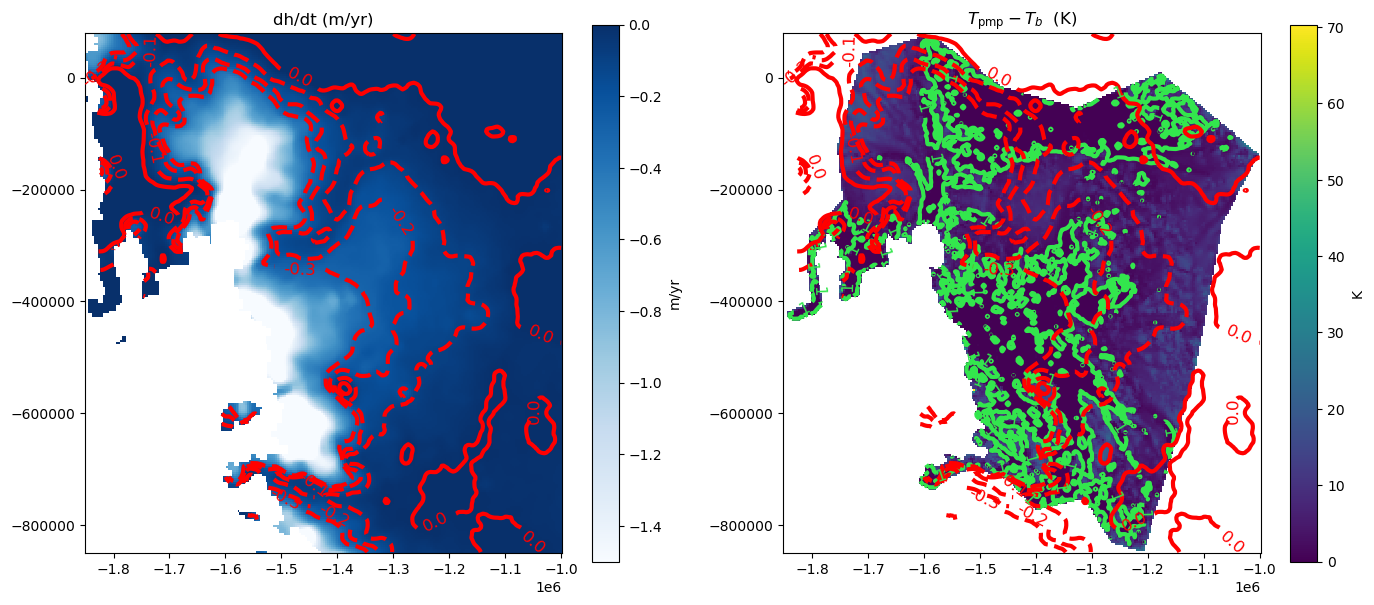

In [37]:
%reload_ext autoreload
%autoreload 2
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import rasterio
from rasterio.transform import xy
import scipy.io as sio
import xarray as xr
from scipy.interpolate import RegularGridInterpolator
import os
from scipy.ndimage import gaussian_filter
import sys
sys.path.append('../')
from src.ice import delta_driving_stress
from src.ice import driving_stress

# ─────────────────────────────────────────────
# Directory & File Paths
# ─────────────────────────────────────────────
dhdt_dir  = '/data-archive/download-extended/ICESat1_ICESat2_mass_change_updated_2_2021 (1)/ICESat1_ICESat2_mass_change_updated_2_2021/dhdt/'
Tb_dir    = '/home/donglaiyang/Documents/Georgia-Tech/Research/GMR-inference/data/'
Tpmp_dir  = '/home/donglaiyang/Documents/Georgia-Tech/Research/thermal-model/Amundsen-thermal-output-Yang/thermal-training-data/Thwaites-PIG/training/gridded/'

dhdt_file  = os.path.join(dhdt_dir,  'ais_dhdt_grounded.tif')
Tb_file    = os.path.join(Tb_dir,    'posterior_mean_Tb.tif')
mask_file  = os.path.join(Tpmp_dir,  'training_mask_domain_continuous.mat')
H_file     = os.path.join(Tpmp_dir,  'H_gridded.mat')
coord_file = os.path.join(Tpmp_dir,  'trainingAll_image_coord.mat')

# ─────────────────────────────────────────────
# Helper: build a meshgrid from a rasterio dataset
# ─────────────────────────────────────────────
def world_grid(src):
    """Return (X, Y) 2-D coordinate arrays matching the raster grid."""
    rows = np.arange(src.height)
    cols = np.arange(src.width)
    # xy() returns (row-centre x, row-centre y) for every pixel
    xs = np.array([src.xy(0, c)[0] for c in cols])   # 1-D x vector
    ys = np.array([src.xy(r, 0)[1] for r in rows])   # 1-D y vector
    X, Y = np.meshgrid(xs, ys)
    return X, Y, xs, ys

# ─────────────────────────────────────────────
# Load Smith et al. 2020  dhdt
# ─────────────────────────────────────────────
with rasterio.open(dhdt_file) as src:
    dhdt = src.read(1).astype(np.float64)
    nodata = src.nodata
    if nodata is not None:
        dhdt[dhdt == nodata] = np.nan
    X, Y, xs, ys = world_grid(src)

# ─────────────────────────────────────────────
# Load basal temperature  Tb
# ─────────────────────────────────────────────
with rasterio.open(Tb_file) as src:
    Tb = src.read(1).astype(np.float64)
    nodata = src.nodata
    if nodata is not None:
        Tb[Tb == nodata] = np.nan
    X_ase, Y_ase, xs_ase, ys_ase = world_grid(src)

# ─────────────────────────────────────────────
# Interpolate dhdt onto ASE coordinate grid
# ─────────────────────────────────────────────
# RegularGridInterpolator expects axes in ascending order.
# rasterio grids typically have ys descending → flip if needed.

if ys[0] > ys[-1]:          # descending → flip
    interp_fn = RegularGridInterpolator(
        (ys[::-1], xs),
        dhdt[::-1, :],
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )
else:
    interp_fn = RegularGridInterpolator(
        (ys, xs),
        dhdt,
        method='linear',
        bounds_error=False,
        fill_value=np.nan
    )

# Query points: shape (N, 2) with (y, x) ordering
pts = np.column_stack([Y_ase.ravel(), X_ase.ravel()])
dhdt_ase = interp_fn(pts).reshape(X_ase.shape)

# ─────────────────────────────────────────────
# Load .mat files
# ─────────────────────────────────────────────
mask_data  = sio.loadmat(mask_file)
H_data     = sio.loadmat(H_file)
coord_data = sio.loadmat(coord_file)

# ─────────────────────────────────────────────
# Compute pressure-melting point  Tpmp
# ─────────────────────────────────────────────
def computePMP(H):
    """
    Pressure-melting point depression.
    Tpmp = T_surface_melting - β * ρ_ice * g * H
    Returns temperature in Kelvin (same reference as Tb).

    Adjust the constant β if your MATLAB version differs.
    """
    beta  = 9.8e-8   # K Pa⁻¹  (Clausius–Clapeyron for ice)
    rho   = 917.0    # kg m⁻³
    g     = 9.81     # m s⁻²
    return 273.15 - beta * rho * g * H   # K

H = H_data['H_struct'][0, 0]['H']       # adjust field access if needed
Tpmp = computePMP(H)

# ─────────────────────────────────────────────
# Plot
# ─────────────────────────────────────────────
levels1 = [-0.3, -0.2, -0.1, 0.0]

fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# ── Left: dhdt_ase ───────────────────────────
ax = axes[0]
im1 = ax.pcolormesh(
    X_ase, Y_ase, dhdt_ase,
    cmap='Blues',
    vmin=-1.5, vmax=0,
    shading='auto'
)
plt.colorbar(im1, ax=ax, label='m/yr')

cs1 = ax.contour(
    xs_ase, ys_ase, dhdt_ase,
    levels=levels1,
    colors='red',
    linewidths=3
)
ax.clabel(cs1, fmt='%.1f', fontsize=12, inline=True)
ax.set_title('dh/dt (m/yr)')
ax.set_aspect('equal')

# ── Right: Tpmp - Tb ─────────────────────────
dT = Tpmp - Tb    # positive = below melting point

ax = axes[1]
im2 = ax.pcolormesh(
    X_ase, Y_ase, dT,
    cmap='viridis',
    shading='auto'
)
plt.colorbar(im2, ax=ax, label='K')

# dT = 1 boundary (green)
cs2 = ax.contour(
    xs_ase, ys_ase, dT,
    levels=[1.0],
    colors=[[0.2, 0.9, 0.3]],
    linewidths=3
)
ax.clabel(cs2, fmt='%.0f', fontsize=12, inline=True)

# dhdt contours overlaid (red)
cs3 = ax.contour(
    xs_ase, ys_ase, dhdt_ase,
    levels=levels1,
    colors='red',
    linewidths=3
)
ax.clabel(cs3, fmt='%.1f', fontsize=12, inline=True)

ax.set_title(r'$T_{\mathrm{pmp}} - T_b$  (K)')
ax.set_aspect('equal')

plt.tight_layout()
os.makedirs('figs', exist_ok=True)
plt.savefig('figs/dhdt_Tb.png', dpi=300, bbox_inches='tight')
plt.show()


In [ ]:
# assume the dt is n years, compute the total slope change
dt_duration = 16 # 2003 to 2019
s_change = dhdt_ase * dt_duration
# use gradient to compute slope change
slope_change_x, slope_change_y = np.gradient(s_change, xs_ase, ys_ase)
slope_change_magnitude = np.sqrt(slope_change_x**2 + slope_change_y**2)
# slope_change_magnitude_smooth = gaussian_filter(slope_change_magnitude, sigma=4)

# import surface DEM and ice thickness
# bedmap load in
bedmap_path = "/home/donglaiyang/Documents/Georgia-Tech/Research/common-data-set/bed-topography/bedmap3AIS.nc"
bedmap_ds = xr.open_dataset(bedmap_path)
bedmap_x = bedmap_ds['x'].values
bedmap_y = bedmap_ds['y'].values
bedmap_s = bedmap_ds['surface_topography'].values
bedmap_b = bedmap_ds['bed_topography'].values
bedmap_h = bedmap_ds['ice_thickness'].values

# import our slope threshold (.npy files)
slope_threshold = np.load('../data/output-slope-perturbation/first_crossing_fracs.npy')
slope_original  = np.load('../data/output-slope-perturbation/slope_magnitude_smooth_interp.npy')
valid_pixel     = np.load('../data/output-slope-perturbation/valid_pixel_revised_idx.npy')

# load mask
data_path = os.getenv('DATA_PATH')
mask_path = data_path + 'training_mask_domain_continuous.mat'
model_bound_data = sio.loadmat(mask_path)
model_bound_data = model_bound_data['in_domain_mask']

slope_threshold_full = np.nan * np.ones_like(slope_original.flatten())
slope_threshold_full[valid_pixel] = slope_threshold
slope_threshold_full = slope_threshold_full.reshape(slope_original.shape)




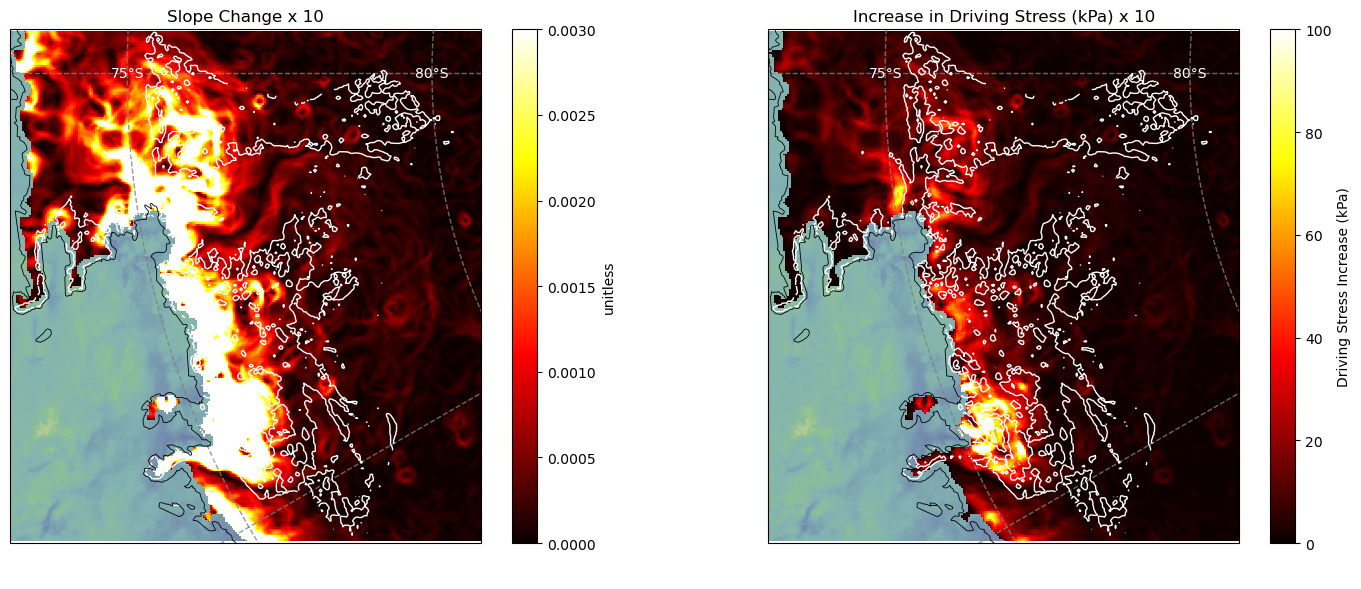

In [61]:
from cartopy.mpl.gridliner import LONGITUDE_FORMATTER, LATITUDE_FORMATTER
import cartopy.feature as cfeature
import cartopy.crs as ccrs

x_min, x_max = np.min(xs_ase), np.max(xs_ase)
y_min, y_max = np.min(ys_ase), np.max(ys_ase)

# preparing hillshade DEM
buffer = 50000  # 50 km buffer in meters
mask_x = (bedmap_x >= x_min - buffer) & (bedmap_x <= x_max + buffer)
mask_y = (bedmap_y >= y_min - buffer) & (bedmap_y <= y_max + buffer)
sdem_crop = bedmap_s[np.ix_(mask_y, mask_x)]
bdem_crop = bedmap_b[np.ix_(mask_y, mask_x)]
x_crop   = bedmap_x[mask_x]
y_crop   = bedmap_y[mask_y]

# interpolate sdem_crop to xs_ase, ys_ase grid
interp_fn_sdem = RegularGridInterpolator(
    (y_crop, x_crop),
    sdem_crop,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)
pts_ase = np.column_stack([Y_ase.ravel(), X_ase.ravel()])
sdem_ase = interp_fn_sdem(pts_ase).reshape(X_ase.shape)
interp_fn_bdem = RegularGridInterpolator(
    (y_crop, x_crop),
    bdem_crop,
    method='linear',
    bounds_error=False,
    fill_value=np.nan
)
bdem_ase = interp_fn_bdem(pts_ase).reshape(X_ase.shape)

# compute slope change and driving stress change
slope_change_pred = slope_original.flatten() * slope_threshold_full.flatten()
dtaud_pred = delta_driving_stress(slope_change_pred, sdem_ase.flatten())
slope_change_pred = slope_change_pred.reshape(256, 256)
dtaud_pred = dtaud_pred.reshape(256, 256)

# -------------------------------------- ICESAT-2 observation -----------------------------------------
# slope change fraction
slope_change_fraction_obs = slope_change_magnitude / slope_original

# increase in driving stress
dtaud_obs = delta_driving_stress(slope_change_magnitude.flatten(), sdem_ase.flatten())
dtaud_obs = dtaud_obs.reshape(256, 256)

# ----------------------------------------
proj     = ccrs.SouthPolarStereo()
data_crs = ccrs.epsg(3031)
def setup_ax(ax):

    ax.set_extent([x_min, x_max, y_min, y_max], crs=data_crs)
    ax.add_feature(cfeature.COASTLINE, zorder=3, edgecolor='black', linewidth=0.6)

    gl = ax.gridlines(
        crs=ccrs.PlateCarree(),
        draw_labels=True,
        linewidth=1, color='grey', alpha=0.8, linestyle='--', zorder=5
    )
    gl.top_labels   = False
    gl.right_labels = False
    gl.xlabel_style = {'size': 10, 'color': 'white'}
    gl.ylabel_style = {'size': 10, 'color': 'white'}
    gl.xlocator   = plt.FixedLocator(range(-180, 181, 30))
    gl.ylocator   = plt.FixedLocator(range(-90, -59, 5))
    gl.xformatter = LONGITUDE_FORMATTER
    gl.yformatter = LATITUDE_FORMATTER

    # Hillshade (shared background)
    ax.imshow(
        bdem_ase,
        origin='upper',
        extent=[x_min, x_max, y_min, y_max],
        transform=data_crs,
        cmap='gist_earth', alpha=0.6, zorder=0
    )

    return gl

fig, axes = plt.subplots(1, 2,
    figsize=(16, 6),                          # ← wider to fit three panels
    subplot_kw={'projection': proj}
)
setup_ax(axes[0])
im0 = axes[0].imshow(
    slope_change_magnitude * 10,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot',                          
    alpha=1, zorder=1,
    vmin=0, vmax=0.003
)
axes[0].set_title('Slope Change x 10')
axes[0].set_aspect('equal')
# add colorbar
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04,
             label='unitless')
# add dT contour
cs1 = axes[0].contour(
    xs_ase, ys_ase, dT,
    levels=[1],
    colors='white',
    linewidths=1,
    transform=data_crs,
    zorder=2
)

setup_ax(axes[1])
im1 = axes[1].imshow(
    dtaud_obs / 1e3 * 10,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot',                          
    alpha=1, zorder=1,
    vmin=0, vmax=100
)
axes[1].set_title('Increase in Driving Stress (kPa) x 10')
axes[1].set_aspect('equal')
fig.colorbar(im1, ax=axes[1], fraction=0.046, pad=0.04,
             label='Driving Stress Increase (kPa)')
# add dT contour
cs1 = axes[1].contour(
    xs_ase, ys_ase, dT,
    levels=[1],
    colors='white',
    linewidths=1,
    transform=data_crs,
    zorder=2
)
plt.tight_layout()
plt.show()


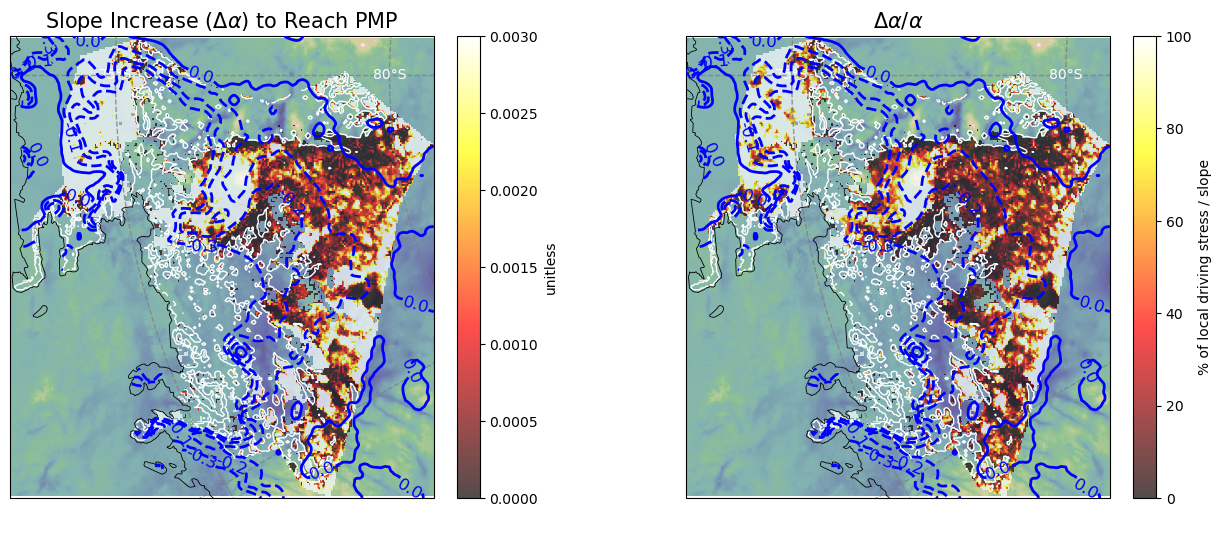

In [59]:
# compute driving stress increase fraction compared to original driving stress
# original driving stress
slope_original_flat = slope_original.flatten()
tau_original = driving_stress(slope_original_flat, sdem_ase.flatten())
dtaud_fraction_pred = dtaud_pred / tau_original.reshape(256, 256)

plot_dhdt = True

fig, axes = plt.subplots(1, 2,
    figsize=(16, 6),                          # ← wider to fit three panels
    subplot_kw={'projection': proj}
)

setup_ax(axes[0])
im0 = axes[0].imshow(
    slope_change_pred,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot', vmin=0, vmax=0.003,
    alpha=0.7, zorder=1
)

cs0 = axes[0].contour(
    xs_ase, ys_ase, dT,
    levels=[0.5],
    colors='white',
    linewidths=1,
    transform=data_crs,
    zorder=2
)
if plot_dhdt:
    cs1 = axes[0].contour(
        xs_ase, ys_ase, dhdt_ase,
        levels=levels1,
        colors='blue',
        linewidths=2,
        transform=data_crs,
        zorder=3
    )
    ax.clabel(cs1, fmt='%.1f', fontsize=12, inline=True)


axes[0].set_title(rf"Slope Increase ($\Delta \alpha$) to Reach PMP ", fontsize=15)
fig.colorbar(im0, ax=axes[0], fraction=0.046, pad=0.04,
             label='unitless')

# ---------------------------------------
setup_ax(axes[1])
im0 = axes[1].imshow(
    dtaud_fraction_pred * 100,
    origin='lower',
    extent=[x_min, x_max, y_min, y_max],
    transform=data_crs,
    cmap='hot', vmin=0, vmax=100,
    alpha=0.7, zorder=1
)

cs0 = axes[1].contour(
    xs_ase, ys_ase, dT,
    levels=[0.5],
    colors='white',
    linewidths=1,
    transform=data_crs,
    zorder=2
)

if plot_dhdt:
    cs1 = axes[1].contour(
        xs_ase, ys_ase, dhdt_ase,
        levels=levels1,
        colors='blue',
        linewidths=2,
        transform=data_crs,
        zorder=3
    )
    ax.clabel(cs1, fmt='%.1f', fontsize=12, inline=True)


axes[1].set_title(rf"$\Delta \alpha / \alpha$", fontsize=15)
fig.colorbar(im0, ax=axes[1], fraction=0.046, pad=0.04,
             label='% of local driving stress / slope')
# ---------------------------------------
if plot_dhdt:
    plt.savefig('../figs/slope_change_pred_with_dhdt.png', dpi=300, bbox_inches='tight')
else:
    plt.savefig('../figs/slope_change_pred.png', dpi=300, bbox_inches='tight')

